# Binary Classification — APTOS 2019 Dataset

## Diabetic Retinopathy: No DR vs. DR Present

A **self-contained** notebook that handles the full pipeline on the APTOS 2019 dataset only:

| Stage | Detail |
|---|---|
| Data | APTOS 2019 — 3,534 preprocessed fundus images |
| Split | 70 / 15 / 15 stratified on binary_label |
| Model | EfficientNet-B3 (ImageNet pretrained, timm) |
| Head | Dropout(0.4) → Linear(1536, 1) |
| Loss | BCEWithLogitsLoss + pos_weight |
| Strategy | Phase 1: frozen 5 ep → Phase 2: fine-tune 30 ep |
| Metric | AUC-ROC (primary), Accuracy |

---

In [2]:
# ============================================================
# 1. Imports & Configuration
# ============================================================
import os, gc, copy, time, random, warnings, json
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    accuracy_score, confusion_matrix, classification_report,
    cohen_kappa_score, matthews_corrcoef, f1_score,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ──
SEED = 42
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
set_seed(SEED)

# ── Device ──
def get_device() -> torch.device:
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()

# ── Configuration ──
CONFIG = {
    "seed": SEED,
    "device": str(DEVICE),
    "data_root": ".",
    "input_csv": "merged_labels_preprocessed.csv",
    "dataset_filter": "aptos2019",
    # Outputs
    "splits_dir": "splits_aptos",
    "models_dir": "models",
    "figures_dir": "figures",
    # Model
    "model_name": "efficientnet_b3",
    "pretrained": True,
    "num_classes": 1,
    "dropout_rate": 0.4,
    # Image
    "image_size": 384,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    # Training
    "phase1_epochs": 5,
    "phase1_lr": 1e-3,
    "phase2_epochs": 30,
    "phase2_lr": 1e-4,
    "weight_decay": 1e-4,
    "scheduler_T0": 10,
    "scheduler_Tmult": 2,
    # DataLoader
    "batch_size": 16,
    "num_workers": 0,
    "pin_memory": False,
    # Regularisation
    "grad_clip_max_norm": 1.0,
    "early_stopping_patience": 10,
    "use_amp": DEVICE.type == "cuda",
}

ROOT = Path(CONFIG["data_root"])
SPLITS_DIR = ROOT / CONFIG["splits_dir"]
MODELS_DIR = ROOT / CONFIG["models_dir"]
FIG_DIR = ROOT / CONFIG["figures_dir"]
for d in [SPLITS_DIR, MODELS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Device        : {DEVICE}")
print(f"Dataset       : APTOS 2019 only")
print(f"Model         : {CONFIG['model_name']}")
print(f"Image size    : {CONFIG['image_size']}×{CONFIG['image_size']}")
print(f"Phase 1       : {CONFIG['phase1_epochs']} epochs (frozen), lr={CONFIG['phase1_lr']}")
print(f"Phase 2       : {CONFIG['phase2_epochs']} epochs (fine-tune), lr={CONFIG['phase2_lr']}")
print(f"Batch size    : {CONFIG['batch_size']}")
print(f"Early stopping: patience={CONFIG['early_stopping_patience']}")
print("Configuration loaded ✓")


Device        : mps
Dataset       : APTOS 2019 only
Model         : efficientnet_b3
Image size    : 384×384
Phase 1       : 5 epochs (frozen), lr=0.001
Phase 2       : 30 epochs (fine-tune), lr=0.0001
Batch size    : 16
Early stopping: patience=10
Configuration loaded ✓


In [1]:
print("e")

e


## 2. Load APTOS 2019 & Create Stratified Splits

Filter the merged CSV to APTOS images only, then create 70/15/15 train/val/test splits stratified on `binary_label`.

In [2]:
# ============================================================
# 2. Load APTOS 2019 data and split
# ============================================================
df_all = pd.read_csv(ROOT / CONFIG["input_csv"])
df = df_all[df_all["original_dataset"] == CONFIG["dataset_filter"]].reset_index(drop=True)

print(f"APTOS 2019: {len(df)} images")
print(f"\nBinary distribution:")
print(df["binary_label"].value_counts().sort_index().to_string())
print(f"\nDR grade distribution:")
print(df["dr_grade"].value_counts().sort_index().to_string())

# Verify files exist
missing = [p for p in df["preprocessed_path"] if not (ROOT / p).exists()]
if missing:
    print(f"\nWARNING: {len(missing)} files missing!")
else:
    print(f"\nAll {len(df)} preprocessed files verified ✓")

# ── Stratified 70/15/15 split ──
df_train, df_temp = train_test_split(
    df, test_size=0.30, stratify=df["binary_label"], random_state=SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, stratify=df_temp["binary_label"], random_state=SEED
)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"\nSplit sizes:")
print(f"  Train : {len(df_train):5d} ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val   : {len(df_val):5d} ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test  : {len(df_test):5d} ({len(df_test)/len(df)*100:.1f}%)")
print(f"  Total : {len(df_train)+len(df_val)+len(df_test)}")

# Leakage check
assert len(set(df_train["image_id"]) & set(df_val["image_id"])) == 0
assert len(set(df_train["image_id"]) & set(df_test["image_id"])) == 0
assert len(set(df_val["image_id"]) & set(df_test["image_id"])) == 0
print("✓ Zero data leakage")

# Binary proportions
for name, split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    pos = (split["binary_label"] == 1).mean() * 100
    print(f"  {name}: {pos:.1f}% DR")

# Save splits
df_train.to_csv(SPLITS_DIR / "train_split.csv", index=False)
df_val.to_csv(SPLITS_DIR / "val_split.csv", index=False)
df_test.to_csv(SPLITS_DIR / "test_split.csv", index=False)
print(f"\nSplits saved → {SPLITS_DIR}/")


APTOS 2019: 3534 images

Binary distribution:
binary_label
0    1798
1    1736

DR grade distribution:
dr_grade
0    1798
1     341
2     934
3     182
4     279

All 3534 preprocessed files verified ✓

Split sizes:
  Train :  2473 (70.0%)
  Val   :   530 (15.0%)
  Test  :   531 (15.0%)
  Total : 3534
✓ Zero data leakage
  Train: 49.1% DR
  Val: 49.1% DR
  Test: 49.2% DR

Splits saved → splits_aptos/


## 3. Quick EDA — APTOS Class Distribution

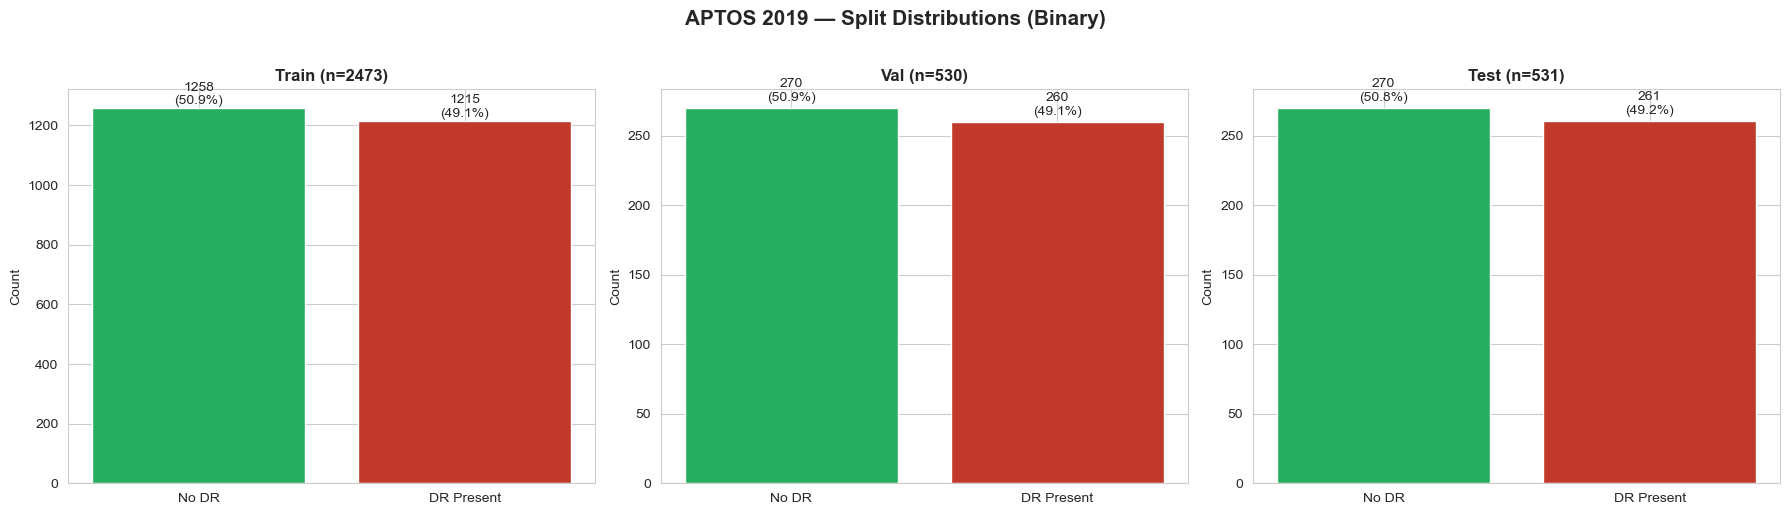

Saved → figures/aptos_binary_split_distribution.png


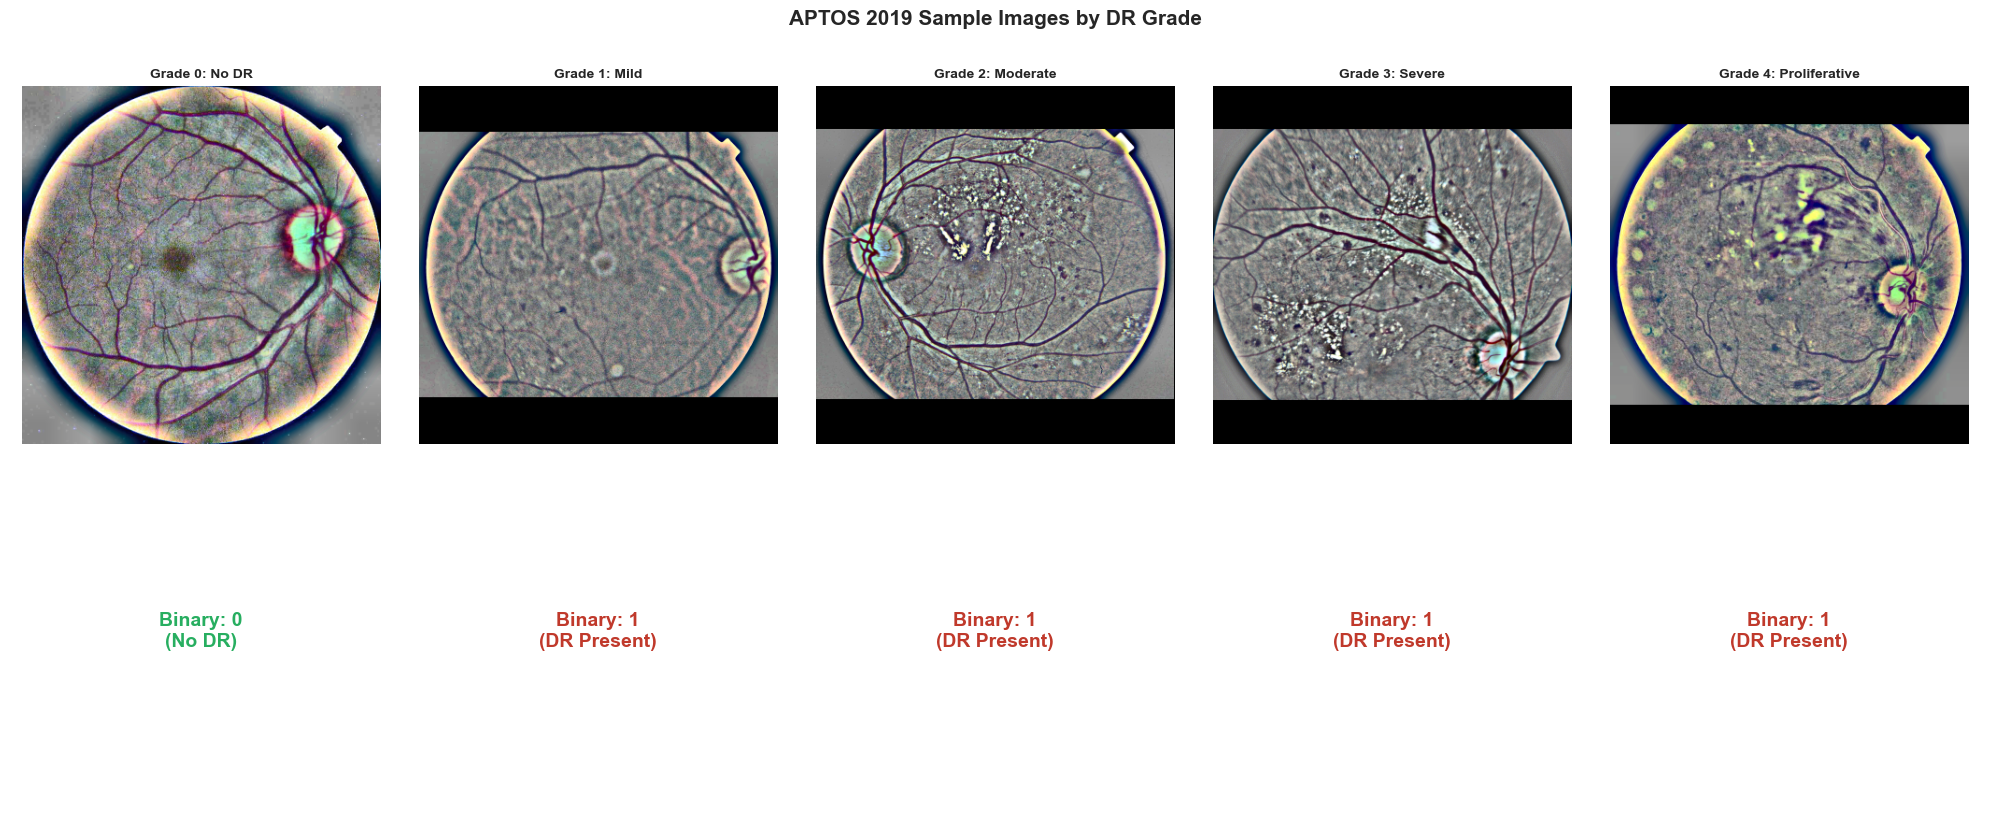

In [3]:
# ============================================================
# 3. Class distribution visualization
# ============================================================
grade_names = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative"}
palette_5 = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
palette_2 = ["#27ae60", "#c0392b"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("APTOS 2019 — Split Distributions (Binary)", fontsize=15, fontweight="bold", y=1.02)

for i, (name, split) in enumerate([("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    ax = axes[i]
    counts = split["binary_label"].value_counts().sort_index()
    bars = ax.bar(["No DR", "DR Present"], [counts.get(0, 0), counts.get(1, 0)],
                  color=palette_2, edgecolor="white")
    ax.set_title(f"{name} (n={len(split)})", fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    for bar, b in zip(bars, [0, 1]):
        v = counts.get(b, 0)
        pct = v / len(split) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f"{v}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "aptos_binary_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'aptos_binary_split_distribution.png'}")

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("APTOS 2019 Sample Images by DR Grade", fontsize=15, fontweight="bold", y=1.02)
for grade in range(5):
    sub = df_train[df_train["dr_grade"] == grade]
    if len(sub) > 0:
        row = sub.sample(1, random_state=SEED).iloc[0]
        img = cv2.imread(str(ROOT / row["preprocessed_path"]))
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[0, grade].imshow(img_rgb)
            axes[0, grade].set_title(f"Grade {grade}: {grade_names[grade]}", fontsize=10, fontweight="bold")
    axes[0, grade].axis("off")
    axes[1, grade].axis("off")

    # Binary label overlay
    if grade == 0:
        axes[1, grade].text(0.5, 0.5, "Binary: 0\n(No DR)", ha="center", va="center",
                            fontsize=14, color="#27ae60", fontweight="bold", transform=axes[1, grade].transAxes)
    else:
        axes[1, grade].text(0.5, 0.5, f"Binary: 1\n(DR Present)", ha="center", va="center",
                            fontsize=14, color="#c0392b", fontweight="bold", transform=axes[1, grade].transAxes)

plt.tight_layout()
plt.savefig(FIG_DIR / "aptos_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Dataset & DataLoader

In [4]:
# ============================================================
# 4. Dataset, augmentation, and DataLoaders
# ============================================================

def get_train_transforms(image_size: int, mean: list, std: list) -> A.Compose:
    """Training augmentation pipeline."""
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=30,
                           border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        A.CoarseDropout(
            num_holes_range=(1, 3),
            hole_height_range=(int(image_size * 0.05), int(image_size * 0.15)),
            hole_width_range=(int(image_size * 0.05), int(image_size * 0.15)),
            fill="random", p=0.3,
        ),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ])


def get_val_transforms(image_size: int, mean: list, std: list) -> A.Compose:
    """Validation / test transforms (deterministic)."""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ])


class DRDataset(Dataset):
    """Diabetic Retinopathy dataset for binary classification."""

    def __init__(self, dataframe: pd.DataFrame, transform: A.Compose,
                 root: Path = Path(".")) -> None:
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.root = root

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        row = self.df.iloc[idx]
        img_path = str(self.root / row["preprocessed_path"])
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Cannot read: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = self.transform(image=img)
        image = augmented["image"]
        label = torch.tensor([row["binary_label"]], dtype=torch.float32)
        return image, label

    def get_pos_weight(self) -> torch.Tensor:
        """Compute pos_weight for BCEWithLogitsLoss."""
        labels = self.df["binary_label"].values
        n_neg = (labels == 0).sum()
        n_pos = (labels == 1).sum()
        return torch.tensor([n_neg / n_pos], dtype=torch.float32)


# Create DataLoaders
train_tfm = get_train_transforms(CONFIG["image_size"], CONFIG["mean"], CONFIG["std"])
val_tfm = get_val_transforms(CONFIG["image_size"], CONFIG["mean"], CONFIG["std"])

train_ds = DRDataset(df_train, train_tfm, ROOT)
val_ds = DRDataset(df_val, val_tfm, ROOT)
test_ds = DRDataset(df_test, val_tfm, ROOT)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                          num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"],
                          drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                        num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"])
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"])

pos_weight = train_ds.get_pos_weight().to(DEVICE)

print(f"Train : {len(train_ds):,} images → {len(train_loader)} batches")
print(f"Val   : {len(val_ds):,} images → {len(val_loader)} batches")
print(f"Test  : {len(test_ds):,} images → {len(test_loader)} batches")
print(f"pos_weight: {pos_weight.item():.4f}")

# Sanity: load one batch
imgs, lbls = next(iter(train_loader))
print(f"\nBatch check: images={list(imgs.shape)}, labels={list(lbls.shape)}")
print(f"  pixel range: [{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"  label values: {lbls.unique().flatten().tolist()}")
print("✓ DataLoaders ready")


Train : 2,473 images → 154 batches
Val   : 530 images → 34 batches
Test  : 531 images → 34 batches
pos_weight: 1.0354

Batch check: images=[16, 3, 384, 384], labels=[16, 1]
  pixel range: [-2.12, 2.64]
  label values: [0.0, 1.0]
✓ DataLoaders ready


## 5. Model Architecture

**EfficientNet-B3** (12.2M params, 1536-d features) with custom binary head:

```
EfficientNet-B3 backbone (ImageNet pretrained)
    └─ Global Average Pooling
        └─ Dropout(0.4)
            └─ Linear(1536 → 1)
```

In [5]:
# ============================================================
# 5. Create model
# ============================================================
model = timm.create_model(CONFIG["model_name"], pretrained=CONFIG["pretrained"])
n_features = model.num_features  # 1536

model.classifier = nn.Sequential(
    nn.Dropout(p=CONFIG["dropout_rate"]),
    nn.Linear(n_features, 1),
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model         : {CONFIG['model_name']}")
print(f"Features      : {n_features}")
print(f"Total params  : {total_params:,}")
print(f"Trainable     : {trainable_params:,}")
print(f"Device        : {DEVICE}")


Model         : efficientnet_b3
Features      : 1536
Total params  : 10,697,769
Trainable     : 10,697,769
Device        : mps


## 6. Training Utilities

In [6]:
# ============================================================
# 6. Training utilities
# ============================================================

class EarlyStopping:
    """Stop training when monitored metric stops improving."""
    def __init__(self, patience: int = 10, mode: str = "max") -> None:
        self.patience = patience
        self.mode = mode
        self.counter = 0
        self.best_score: Optional[float] = None
        self.should_stop = False

    def __call__(self, score: float) -> bool:
        if self.best_score is None:
            self.best_score = score
            return False
        improved = score > self.best_score if self.mode == "max" else score < self.best_score
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                return True
        return False


class AverageMeter:
    """Running average tracker."""
    def __init__(self):
        self.reset()
    def reset(self):
        self.avg = 0.0; self.sum = 0.0; self.count = 0
    def update(self, val: float, n: int = 1):
        self.sum += val * n; self.count += n; self.avg = self.sum / self.count


def freeze_backbone(model: nn.Module) -> None:
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Backbone FROZEN — trainable: {t:,}")


def unfreeze_all(model: nn.Module) -> None:
    for param in model.parameters():
        param.requires_grad = True
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  All layers UNFROZEN — trainable: {t:,}")


def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip=1.0):
    """Train for one epoch. Returns (loss, auc, accuracy)."""
    model.train()
    loss_meter = AverageMeter()
    all_labels, all_probs = [], []

    pbar = tqdm(loader, desc="  Train", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        loss_meter.update(loss.item(), images.size(0))
        probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.detach().cpu().numpy().flatten())
        pbar.set_postfix(loss=f"{loss_meter.avg:.4f}")

    all_labels, all_probs = np.array(all_labels), np.array(all_probs)
    try:
        auc_val = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc_val = 0.5
    acc = accuracy_score(all_labels, (all_probs >= 0.5).astype(int))
    return loss_meter.avg, auc_val, acc


@torch.no_grad()
def validate(model, loader, criterion, device):
    """Validate model. Returns (loss, auc, accuracy)."""
    model.eval()
    loss_meter = AverageMeter()
    all_labels, all_probs = [], []

    pbar = tqdm(loader, desc="  Val  ", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss_meter.update(loss.item(), images.size(0))
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy().flatten())
        pbar.set_postfix(loss=f"{loss_meter.avg:.4f}")

    all_labels, all_probs = np.array(all_labels), np.array(all_probs)
    try:
        auc_val = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc_val = 0.5
    acc = accuracy_score(all_labels, (all_probs >= 0.5).astype(int))
    return loss_meter.avg, auc_val, acc


print("Training utilities defined ✓")


Training utilities defined ✓


## 7. Phase 1 — Frozen Backbone (Head Only)

Freeze the pretrained backbone and train only the classifier head for 5 epochs at a higher learning rate.

In [7]:
# ============================================================
# 7. Phase 1: Train head only
# ============================================================
print("=" * 65)
print("PHASE 1: Frozen backbone — classifier head only")
print("=" * 65)

freeze_backbone(model)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"  Loss: BCEWithLogitsLoss(pos_weight={pos_weight.item():.4f})")

optimizer_p1 = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["phase1_lr"], weight_decay=CONFIG["weight_decay"],
)

# History
history = {"epoch": [], "phase": [], "train_loss": [], "train_auc": [],
           "train_acc": [], "val_loss": [], "val_auc": [], "val_acc": [], "lr": []}

best_val_auc = 0.0
best_model_state = None

header = (f"{'Ep':>4s} {'Ph':>4s} {'TrLoss':>8s} {'TrAUC':>7s} {'TrAcc':>7s} "
          f"{'VlLoss':>8s} {'VlAUC':>7s} {'VlAcc':>7s} {'LR':>10s} {'★':>2s}")
print(f"\n{header}")
print("-" * 75)

for epoch in range(1, CONFIG["phase1_epochs"] + 1):
    tl, ta, tac = train_one_epoch(model, train_loader, criterion, optimizer_p1,
                                   DEVICE, CONFIG["grad_clip_max_norm"])
    vl, va, vac = validate(model, val_loader, criterion, DEVICE)

    lr = optimizer_p1.param_groups[0]["lr"]
    is_best = va > best_val_auc
    if is_best:
        best_val_auc = va
        best_model_state = copy.deepcopy(model.state_dict())

    history["epoch"].append(epoch)
    history["phase"].append("P1")
    history["train_loss"].append(tl)
    history["train_auc"].append(ta)
    history["train_acc"].append(tac)
    history["val_loss"].append(vl)
    history["val_auc"].append(va)
    history["val_acc"].append(vac)
    history["lr"].append(lr)

    mark = " ★" if is_best else ""
    print(f"{epoch:4d} {'P1':>4s} {tl:8.4f} {ta:7.4f} {tac:7.4f} "
          f"{vl:8.4f} {va:7.4f} {vac:7.4f} {lr:10.6f}{mark}")

print(f"\nPhase 1 done — Best val AUC: {best_val_auc:.4f}")


PHASE 1: Frozen backbone — classifier head only
  Backbone FROZEN — trainable: 1,537
  Loss: BCEWithLogitsLoss(pos_weight=1.0354)

  Ep   Ph   TrLoss   TrAUC   TrAcc   VlLoss   VlAUC   VlAcc         LR  ★
---------------------------------------------------------------------------


   1   P1   0.3510  0.9453  0.8762   0.2242  0.9707  0.9377   0.001000 ★


   2   P1   0.2262  0.9730  0.9205   0.1824  0.9783  0.9528   0.001000 ★


   3   P1   0.1841  0.9817  0.9432   0.1675  0.9803  0.9528   0.001000 ★


   4   P1   0.1839  0.9811  0.9351   0.1603  0.9814  0.9528   0.001000 ★


   5   P1   0.1889  0.9770  0.9403   0.1593  0.9818  0.9491   0.001000 ★

Phase 1 done — Best val AUC: 0.9818


## 8. Phase 2 — Full Fine-Tuning

Unfreeze all layers and train with differential learning rates (backbone 10× lower). CosineAnnealingWarmRestarts scheduler + early stopping on val AUC.

In [8]:
# ============================================================
# 8. Phase 2: Full fine-tuning
# ============================================================
print("=" * 65)
print("PHASE 2: Full fine-tuning — all layers")
print("=" * 65)

unfreeze_all(model)

optimizer_p2 = AdamW([
    {"params": [p for n, p in model.named_parameters() if "classifier" not in n],
     "lr": CONFIG["phase2_lr"] * 0.1},
    {"params": model.classifier.parameters(),
     "lr": CONFIG["phase2_lr"]},
], weight_decay=CONFIG["weight_decay"])

scheduler = CosineAnnealingWarmRestarts(
    optimizer_p2, T_0=CONFIG["scheduler_T0"], T_mult=CONFIG["scheduler_Tmult"],
)
early_stopper = EarlyStopping(patience=CONFIG["early_stopping_patience"], mode="max")

epoch_offset = CONFIG["phase1_epochs"]
print(f"  Differential LR: backbone={CONFIG['phase2_lr']*0.1:.1e}, head={CONFIG['phase2_lr']:.1e}")
print(f"  Scheduler: CosineAnnealingWarmRestarts(T0={CONFIG['scheduler_T0']}, Tmult={CONFIG['scheduler_Tmult']})")
print(f"  Early stopping: patience={CONFIG['early_stopping_patience']}")

print(f"\n{header}")
print("-" * 75)

for epoch in range(1, CONFIG["phase2_epochs"] + 1):
    global_epoch = epoch_offset + epoch

    tl, ta, tac = train_one_epoch(model, train_loader, criterion, optimizer_p2,
                                   DEVICE, CONFIG["grad_clip_max_norm"])
    vl, va, vac = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    lr = optimizer_p2.param_groups[1]["lr"]
    is_best = va > best_val_auc
    if is_best:
        best_val_auc = va
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save({
            "model_name": CONFIG["model_name"],
            "num_features": n_features,
            "dropout_rate": CONFIG["dropout_rate"],
            "num_classes": CONFIG["num_classes"],
            "image_size": CONFIG["image_size"],
            "mean": CONFIG["mean"],
            "std": CONFIG["std"],
            "model_state_dict": best_model_state,
            "best_val_auc": best_val_auc,
            "epoch": global_epoch,
            "config": CONFIG,
        }, MODELS_DIR / "best_binary_model.pth")

    history["epoch"].append(global_epoch)
    history["phase"].append("P2")
    history["train_loss"].append(tl)
    history["train_auc"].append(ta)
    history["train_acc"].append(tac)
    history["val_loss"].append(vl)
    history["val_auc"].append(va)
    history["val_acc"].append(vac)
    history["lr"].append(lr)

    mark = " ★" if is_best else ""
    print(f"{global_epoch:4d} {'P2':>4s} {tl:8.4f} {ta:7.4f} {tac:7.4f} "
          f"{vl:8.4f} {va:7.4f} {vac:7.4f} {lr:10.6f}{mark}")

    if early_stopper(va):
        print(f"\n  Early stopping at epoch {global_epoch} "
              f"(no improvement for {CONFIG['early_stopping_patience']} epochs)")
        break

    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    gc.collect()

print(f"\nPhase 2 done — Best val AUC: {best_val_auc:.4f}")


PHASE 2: Full fine-tuning — all layers
  All layers UNFROZEN — trainable: 10,697,769
  Differential LR: backbone=1.0e-05, head=1.0e-04
  Scheduler: CosineAnnealingWarmRestarts(T0=10, Tmult=2)
  Early stopping: patience=10

  Ep   Ph   TrLoss   TrAUC   TrAcc   VlLoss   VlAUC   VlAcc         LR  ★
---------------------------------------------------------------------------


   6   P2   0.1602  0.9837  0.9476   0.1385  0.9863  0.9566   0.000098 ★


   7   P2   0.1253  0.9887  0.9623   0.1380  0.9880  0.9660   0.000090 ★


   8   P2   0.1147  0.9906  0.9643   0.1246  0.9903  0.9642   0.000079 ★


   9   P2   0.1041  0.9917  0.9696   0.1298  0.9906  0.9642   0.000065 ★


...

  31   P2   0.0363  0.9991  0.9878   0.1085  0.9952  0.9717   0.000010


  32   P2   0.0556  0.9974  0.9862   0.1095  0.9952  0.9717   0.000005


  33   P2   0.0354  0.9989  0.9907   0.1092  0.9953  0.9698   0.000002


  34   P2   0.0460  0.9983  0.9882   0.1091  0.9954  0.9717   0.000001


  35   P2   0.0426  0.9988  0.9862   0.1055  0.9958  0.9717   0.000100

Phase 2 done — Best val AUC: 0.9958


## 9. Training History & Curves

In [9]:
# ============================================================
# 9. Save training history
# ============================================================
df_history = pd.DataFrame(history)
df_history.to_csv(MODELS_DIR / "binary_training_history.csv", index=False)
print(f"History saved → {MODELS_DIR / 'binary_training_history.csv'}")
print(f"Total epochs: {len(df_history)}, Best val AUC: {best_val_auc:.4f}")
print(df_history.tail(5).to_string(index=False))


History saved → models/binary_training_history.csv
Total epochs: 35, Best val AUC: 0.9958
 epoch phase  train_loss  train_auc  train_acc  val_loss  val_auc  val_acc           lr
    31    P2    0.036321   0.999061   0.987825  0.108539 0.995242 0.971698 9.549150e-06
    32    P2    0.055570   0.997386   0.986201  0.109519 0.995228 0.971698 5.449674e-06
    33    P2    0.035364   0.998891   0.990666  0.109184 0.995271 0.969811 2.447174e-06
    34    P2    0.045955   0.998293   0.988231  0.109053 0.995413 0.971698 6.155830e-07
    35    P2    0.042620   0.998840   0.986201  0.105470 0.995755 0.971698 1.000000e-04


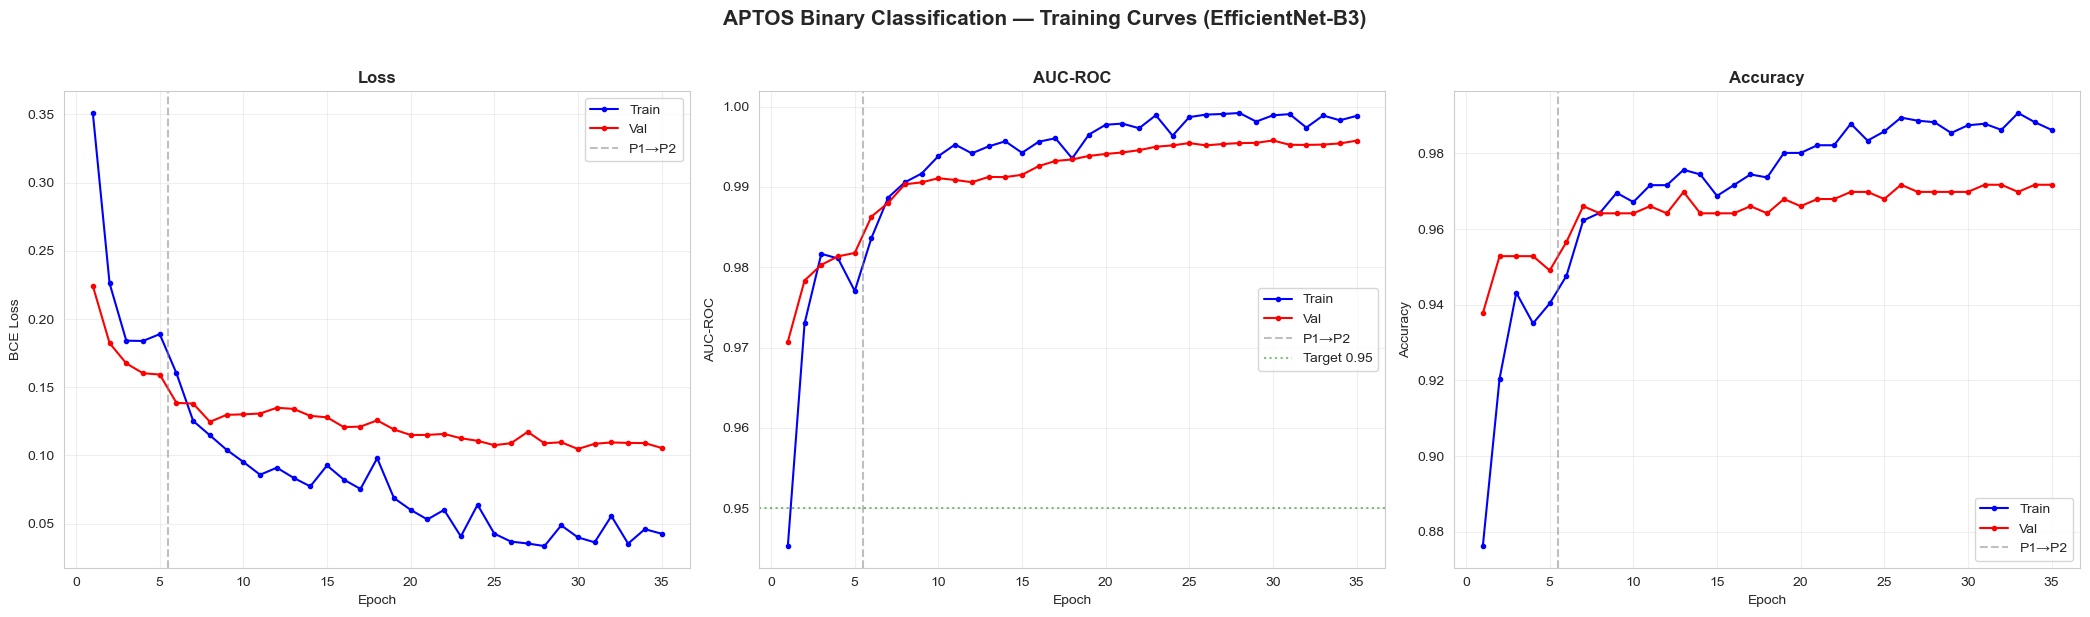

Saved → figures/aptos_binary_training_curves.png


In [10]:
# ============================================================
# 9b. Training curves
# ============================================================
df_h = df_history.copy()
phase1_end = CONFIG["phase1_epochs"]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("APTOS Binary Classification — Training Curves (EfficientNet-B3)",
             fontsize=15, fontweight="bold", y=1.02)

# Loss
ax = axes[0]
ax.plot(df_h["epoch"], df_h["train_loss"], "b-o", label="Train", markersize=3)
ax.plot(df_h["epoch"], df_h["val_loss"], "r-o", label="Val", markersize=3)
ax.axvline(x=phase1_end + 0.5, color="gray", ls="--", alpha=0.5, label="P1→P2")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title("Loss", fontweight="bold"); ax.legend(); ax.grid(True, alpha=0.3)

# AUC
ax = axes[1]
ax.plot(df_h["epoch"], df_h["train_auc"], "b-o", label="Train", markersize=3)
ax.plot(df_h["epoch"], df_h["val_auc"], "r-o", label="Val", markersize=3)
ax.axvline(x=phase1_end + 0.5, color="gray", ls="--", alpha=0.5, label="P1→P2")
ax.axhline(y=0.95, color="green", ls=":", alpha=0.5, label="Target 0.95")
ax.set_xlabel("Epoch"); ax.set_ylabel("AUC-ROC")
ax.set_title("AUC-ROC", fontweight="bold"); ax.legend(); ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[2]
ax.plot(df_h["epoch"], df_h["train_acc"], "b-o", label="Train", markersize=3)
ax.plot(df_h["epoch"], df_h["val_acc"], "r-o", label="Val", markersize=3)
ax.axvline(x=phase1_end + 0.5, color="gray", ls="--", alpha=0.5, label="P1→P2")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy", fontweight="bold"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "aptos_binary_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'aptos_binary_training_curves.png'}")


## 10. Comprehensive Evaluation on Test Set

Load the best model and evaluate on the held-out APTOS test split with full clinical metrics.

In [11]:
# ============================================================
# 10. Evaluate best model on test set
# ============================================================
# Load best model
model.load_state_dict(best_model_state)
model.eval()

all_labels, all_probs = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Test inference"):
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy().flatten())

y_true = np.array(all_labels)
y_prob = np.array(all_probs)

# ── AUC-ROC ──
auc_roc = roc_auc_score(y_true, y_prob)

# ── AUC-PR ──
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
auc_pr = auc(recall_curve, precision_curve)

# ── Optimal threshold (Youden's J) ──
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
J = tpr - fpr
opt_idx = np.argmax(J)
opt_threshold = thresholds[opt_idx]

y_pred = (y_prob >= opt_threshold).astype(int)

# ── Metrics at optimal threshold ──
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
sensitivity = tp / (tp + fn)      # Recall / TPR
specificity = tn / (tn + fp)      # TNR
precision_val = tp / (tp + fp)    # PPV
npv = tn / (tn + fn)              # NPV
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

# ── 95% CI for AUC (bootstrap) ──
np.random.seed(SEED)
boot_aucs = []
for _ in range(1000):
    idx = np.random.choice(len(y_true), len(y_true), replace=True)
    if len(np.unique(y_true[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
ci_lower, ci_upper = np.percentile(boot_aucs, [2.5, 97.5])

# ── Clinical operating points ──
# High-sensitivity (≥0.95)
hi_sens_idx = np.where(tpr >= 0.95)[0]
if len(hi_sens_idx) > 0:
    hi_sens_thresh = thresholds[hi_sens_idx[-1]]
    hi_sens_spec = 1 - fpr[hi_sens_idx[-1]]
else:
    hi_sens_thresh = opt_threshold
    hi_sens_spec = specificity

# High-specificity (≥0.95)
hi_spec_idx = np.where((1 - fpr) >= 0.95)[0]
if len(hi_spec_idx) > 0:
    hi_spec_thresh = thresholds[hi_spec_idx[0]]
    hi_spec_sens = tpr[hi_spec_idx[0]]
else:
    hi_spec_thresh = opt_threshold
    hi_spec_sens = sensitivity

# ── Print results ──
print("=" * 60)
print("BINARY CLASSIFICATION — TEST SET RESULTS (APTOS 2019)")
print("=" * 60)
print(f"  Test images       : {len(y_true)}")
print(f"  Optimal threshold : {opt_threshold:.4f} (Youden's J)")
print()
print(f"  {'Metric':<25s} {'Value':>10s}")
print(f"  {'-'*37}")
print(f"  {'AUC-ROC':<25s} {auc_roc:>10.4f}")
print(f"  {'AUC-ROC 95% CI':<25s} [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  {'AUC-PR':<25s} {auc_pr:>10.4f}")
print(f"  {'Accuracy':<25s} {acc:>10.4f}")
print(f"  {'Sensitivity (Recall)':<25s} {sensitivity:>10.4f}")
print(f"  {'Specificity':<25s} {specificity:>10.4f}")
print(f"  {'Precision (PPV)':<25s} {precision_val:>10.4f}")
print(f"  {'NPV':<25s} {npv:>10.4f}")
print(f"  {'F1-Score':<25s} {f1:>10.4f}")
print(f"  {'Cohen Kappa':<25s} {kappa:>10.4f}")
print(f"  {'MCC':<25s} {mcc:>10.4f}")
print()
print(f"  Clinical Operating Points:")
print(f"  {'High-sens (≥0.95)':<25s} thresh={hi_sens_thresh:.4f}, spec={hi_sens_spec:.4f}")
print(f"  {'High-spec (≥0.95)':<25s} thresh={hi_spec_thresh:.4f}, sens={hi_spec_sens:.4f}")


Test inference: 100%|██████████| 34/34 [00:16<00:00,  2.00it/s]


BINARY CLASSIFICATION — TEST SET RESULTS (APTOS 2019)
  Test images       : 531
  Optimal threshold : 0.4706 (Youden's J)

  Metric                         Value
  -------------------------------------
  AUC-ROC                       0.9992
  AUC-ROC 95% CI            [0.9979, 1.0000]
  AUC-PR                        0.9992
  Accuracy                      0.9906
  Sensitivity (Recall)          0.9923
  Specificity                   0.9889
  Precision (PPV)               0.9885
  NPV                           0.9926
  F1-Score                      0.9904
  Cohen Kappa                   0.9812
  MCC                           0.9812

  Clinical Operating Points:
  High-sens (≥0.95)         thresh=0.0000, spec=0.0000
  High-spec (≥0.95)         thresh=inf, sens=0.0000


## 11. Evaluation Plots

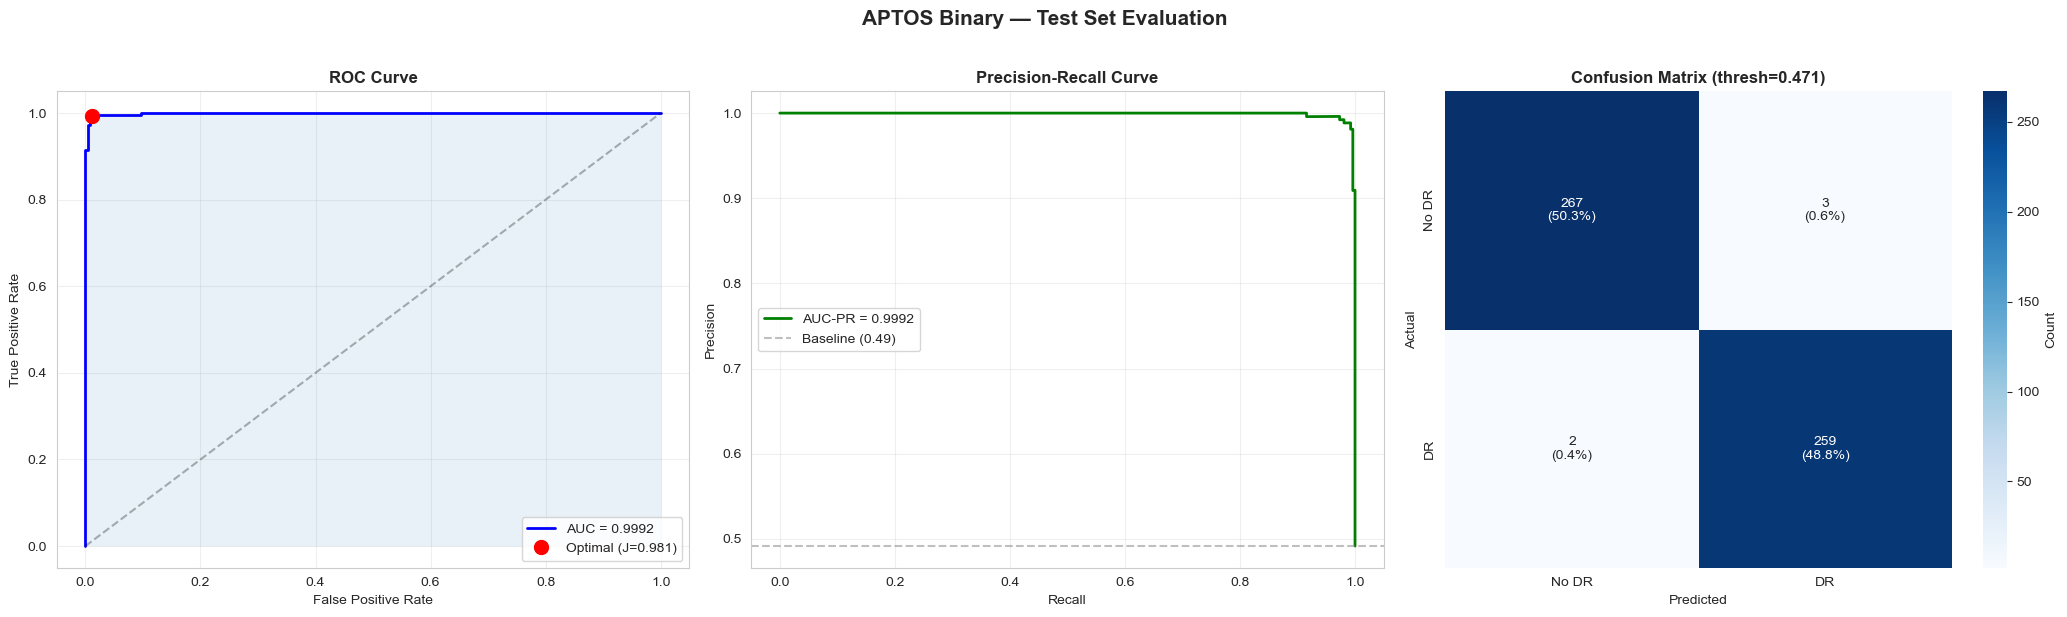

Saved → figures/aptos_binary_evaluation.png


In [12]:
# ============================================================
# 11a. ROC Curve
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("APTOS Binary — Test Set Evaluation", fontsize=15, fontweight="bold", y=1.02)

# ROC
ax = axes[0]
ax.plot(fpr, tpr, "b-", lw=2, label=f"AUC = {auc_roc:.4f}")
ax.plot(fpr[opt_idx], tpr[opt_idx], "ro", markersize=10, label=f"Optimal (J={J[opt_idx]:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.fill_between(fpr, tpr, alpha=0.1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve", fontweight="bold"); ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)

# PR
ax = axes[1]
ax.plot(recall_curve, precision_curve, "g-", lw=2, label=f"AUC-PR = {auc_pr:.4f}")
ax.axhline(y=y_true.mean(), color="gray", ls="--", alpha=0.5, label=f"Baseline ({y_true.mean():.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve", fontweight="bold"); ax.legend(); ax.grid(True, alpha=0.3)

# Confusion Matrix
ax = axes[2]
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm / cm.sum() * 100
labels = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", ax=ax,
            xticklabels=["No DR", "DR"], yticklabels=["No DR", "DR"],
            cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (thresh={opt_threshold:.3f})", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "aptos_binary_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'aptos_binary_evaluation.png'}")


## 12. Save Evaluation Metrics

In [13]:
# ============================================================
# 12. Save all metrics as JSON
# ============================================================
metrics = {
    "dataset": "APTOS 2019",
    "task": "binary",
    "model": CONFIG["model_name"],
    "test_size": int(len(y_true)),
    "optimal_threshold": float(opt_threshold),
    "auc_roc": float(auc_roc),
    "auc_roc_ci_lower": float(ci_lower),
    "auc_roc_ci_upper": float(ci_upper),
    "auc_pr": float(auc_pr),
    "accuracy": float(acc),
    "sensitivity": float(sensitivity),
    "specificity": float(specificity),
    "precision": float(precision_val),
    "npv": float(npv),
    "f1_score": float(f1),
    "cohen_kappa": float(kappa),
    "mcc": float(mcc),
    "high_sensitivity_threshold": float(hi_sens_thresh),
    "high_sensitivity_specificity": float(hi_sens_spec),
    "high_specificity_threshold": float(hi_spec_thresh),
    "high_specificity_sensitivity": float(hi_spec_sens),
}

with open(MODELS_DIR / "aptos_binary_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved → {MODELS_DIR / 'aptos_binary_metrics.json'}")


Metrics saved → models/aptos_binary_metrics.json


## 13. Final Model Checkpoint

In [14]:
# ============================================================
# 13. Ensure final checkpoint is saved
# ============================================================
ckpt_path = MODELS_DIR / "best_binary_model.pth"
if best_model_state is not None:
    checkpoint = {
        "model_name": CONFIG["model_name"],
        "num_features": n_features,
        "dropout_rate": CONFIG["dropout_rate"],
        "num_classes": CONFIG["num_classes"],
        "image_size": CONFIG["image_size"],
        "mean": CONFIG["mean"],
        "std": CONFIG["std"],
        "model_state_dict": best_model_state,
        "best_val_auc": best_val_auc,
        "config": CONFIG,
    }
    torch.save(checkpoint, ckpt_path)
    size_mb = os.path.getsize(ckpt_path) / (1024 * 1024)
    print(f"Model saved → {ckpt_path} ({size_mb:.1f} MB)")
    print(f"Best val AUC: {best_val_auc:.4f}")

# Verify
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
print(f"Checkpoint keys: {list(ckpt.keys())}")
print("✓ Checkpoint verified")


Model saved → models/best_binary_model.pth (41.3 MB)
Best val AUC: 0.9958
Checkpoint keys: ['model_name', 'num_features', 'dropout_rate', 'num_classes', 'image_size', 'mean', 'std', 'model_state_dict', 'best_val_auc', 'config']
✓ Checkpoint verified


## 14. Summary

In [15]:
# ============================================================
# 14. Final summary
# ============================================================
print("=" * 65)
print("APTOS 2019 BINARY CLASSIFICATION — COMPLETE")
print("=" * 65)
print(f"\n  Dataset        : APTOS 2019 ({len(df)} images)")
print(f"  Model          : {CONFIG['model_name']}")
print(f"  Best val AUC   : {best_val_auc:.4f}")
print(f"  Test AUC-ROC   : {auc_roc:.4f} [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  Test Accuracy  : {acc:.4f}")
print(f"  Test Sensitivity: {sensitivity:.4f}")
print(f"  Test Specificity: {specificity:.4f}")
print(f"  Test F1        : {f1:.4f}")
print(f"  Optimal thresh : {opt_threshold:.4f}")
print(f"\n  Outputs:")
print(f"    • {MODELS_DIR / 'best_binary_model.pth'}")
print(f"    • {MODELS_DIR / 'binary_training_history.csv'}")
print(f"    • {MODELS_DIR / 'aptos_binary_metrics.json'}")
print(f"    • {FIG_DIR / 'aptos_binary_training_curves.png'}")
print(f"    • {FIG_DIR / 'aptos_binary_evaluation.png'}")
print(f"    • {SPLITS_DIR}/ (train/val/test CSVs)")

# Cleanup
del model, optimizer_p1, optimizer_p2, scheduler
gc.collect()
if DEVICE.type == "mps":
    torch.mps.empty_cache()
print("\nMemory cleaned up ✓")


APTOS 2019 BINARY CLASSIFICATION — COMPLETE

  Dataset        : APTOS 2019 (3534 images)
  Model          : efficientnet_b3
  Best val AUC   : 0.9958
  Test AUC-ROC   : 0.9992 [0.9979, 1.0000]
  Test Accuracy  : 0.9906
  Test Sensitivity: 0.9923
  Test Specificity: 0.9889
  Test F1        : 0.9904
  Optimal thresh : 0.4706

  Outputs:
    • models/best_binary_model.pth
    • models/binary_training_history.csv
    • models/aptos_binary_metrics.json
    • figures/aptos_binary_training_curves.png
    • figures/aptos_binary_evaluation.png
    • splits_aptos/ (train/val/test CSVs)

Memory cleaned up ✓
